In [1]:
import warnings
warnings.filterwarnings('ignore')

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

# Dataset

In [6]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/eduardofc/data/main/titanic-2.csv")
df.drop(columns=['PassengerId','Name','Ticket'], inplace=True)
df.drop_duplicates(inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Title
0,0,3,male,22.0,1,0,7.2500,NaN,S,Mr
1,1,1,female,38.0,1,0,71.2833,C85,C,Mrs
2,1,3,female,26.0,0,0,7.9250,NaN,S,Miss
3,1,1,female,35.0,1,0,53.1000,C123,S,Mrs
4,0,3,male,35.0,0,0,8.0500,NaN,S,Mr


In [7]:
df.shape

(790, 10)

# Nulos

In [10]:
df1 = df.copy()

In [14]:
# Cabin

df1['Cabin'] = df1['Cabin'].fillna(0)
df1['Cabin'] = df1['Cabin'].apply(lambda x: 0 if x == 0 else 1)

# Embarked

print(len(df))
df1 = df1[~df1.Embarked.isna()]
print(len(df1))

df1.head()

790
788


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Title
0,0,3,male,22.0,1,0,7.2500,0,S,Mr
1,1,1,female,38.0,1,0,71.2833,1,C,Mrs
2,1,3,female,26.0,0,0,7.9250,0,S,Miss
3,1,1,female,35.0,1,0,53.1000,1,S,Mrs
4,0,3,male,35.0,0,0,8.0500,0,S,Mr


In [33]:
""" imputers """

from sklearn.impute import SimpleImputer, KNNImputer

# Age

X = df1[['Age']]

imputer = SimpleImputer(strategy='median')
X_new = imputer.fit_transform(X)

df2 = df1.copy()
df2['Age'] = X_new

In [38]:
df3 = df1.copy()

key_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

X = df3[key_cols]

imputer = KNNImputer(n_neighbors=5, metric='nan_euclidean')
X_new = imputer.fit_transform(X)


df3[key_cols] = X_new

In [39]:
df3.head(6)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Title
0,0,3.0,male,22.0,1.0,0.0,7.2500,0,S,Mr
1,1,1.0,female,38.0,1.0,0.0,71.2833,1,C,Mrs
2,1,3.0,female,26.0,0.0,0.0,7.9250,0,S,Miss
3,1,1.0,female,35.0,1.0,0.0,53.1000,1,S,Mrs
4,0,3.0,male,35.0,0.0,0.0,8.0500,0,S,Mr
5,0,3.0,male,25.0,0.0,0.0,8.4583,0,Q,Mr


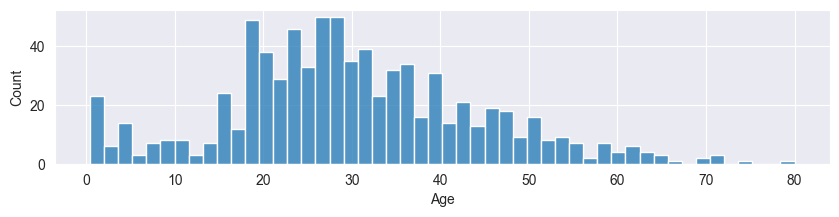

In [40]:
plt.figure(figsize=(10,2))
sns.histplot(data=df3, x='Age', bins=50)
plt.show()

In [26]:
df2.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Cabin       0
Embarked    0
Title       0
dtype: int64

# Plots

In [42]:
cat_cols = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Cabin', 'Embarked', 'Title']
num_cols = ['Age', 'Fare', ]

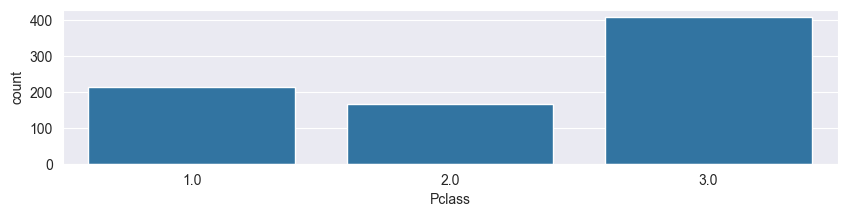

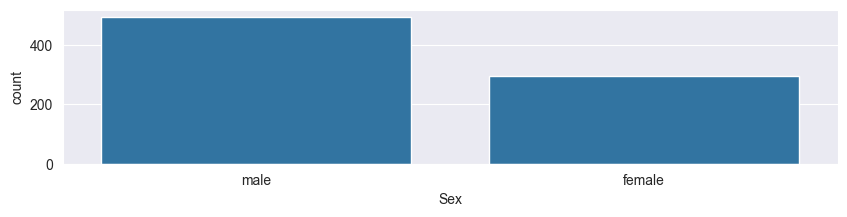

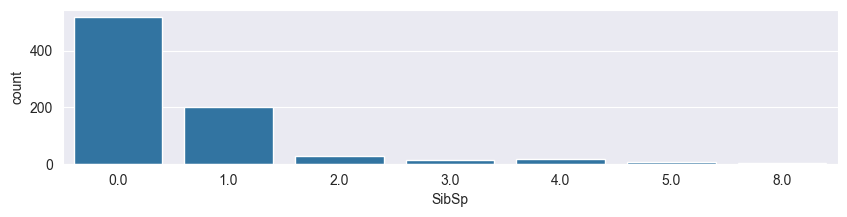

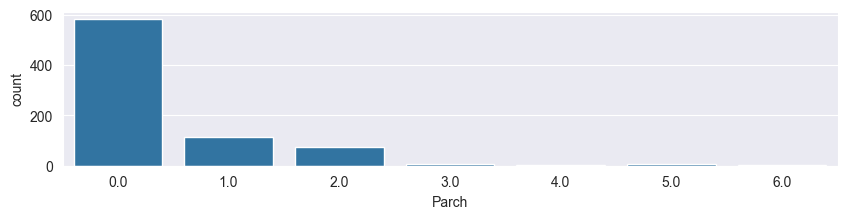

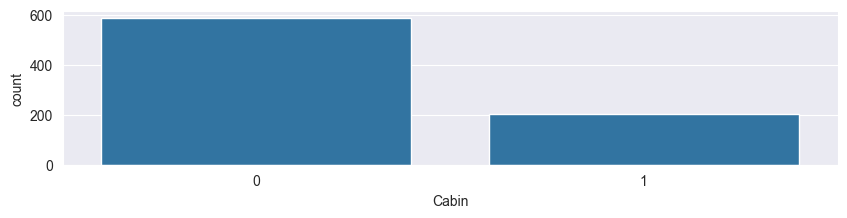

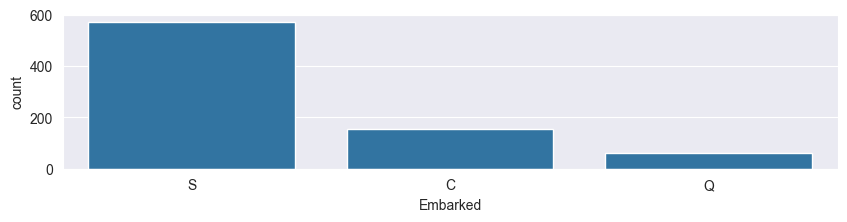

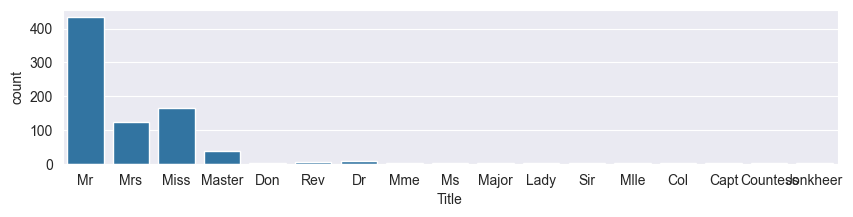

In [43]:
for col in cat_cols:
    plt.figure(figsize=(10,2))
    sns.countplot(data=df3, x=col)
    plt.show()

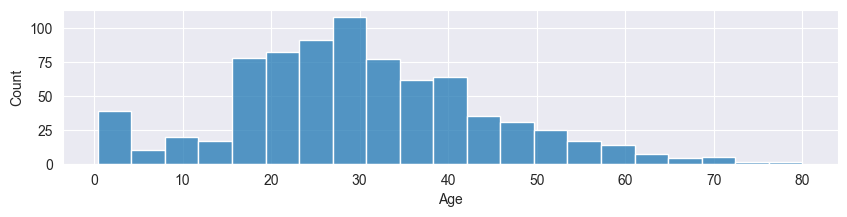

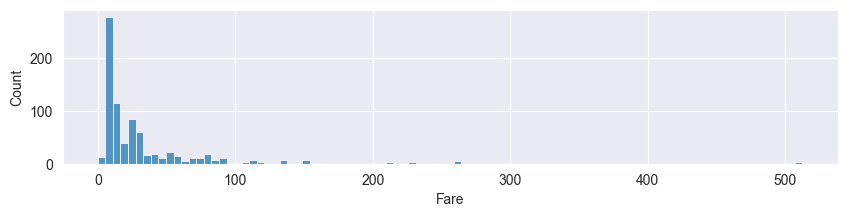

In [44]:
for col in num_cols:
    plt.figure(figsize=(10,2))
    sns.histplot(data=df3, x=col)
    plt.show()

# Transformaciones categóricas

In [45]:
df4 = df3.copy()

df4['SibSp'] = df4['SibSp'].apply(lambda x: 2 if x>=2 else x)
df4['Parch'] = df4['Parch'].apply(lambda x: 2 if x>=2 else x)
df4['Title'] = df4['Title'].apply(lambda x: x if x in ['Mr','Mrs','Miss'] else 'Otros')

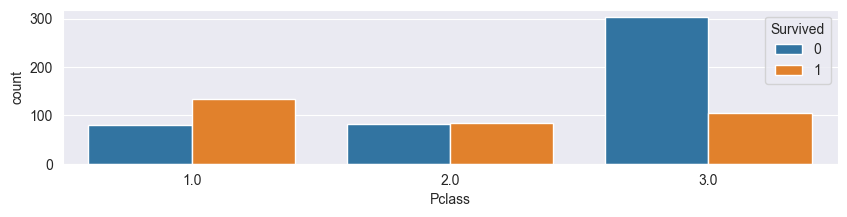

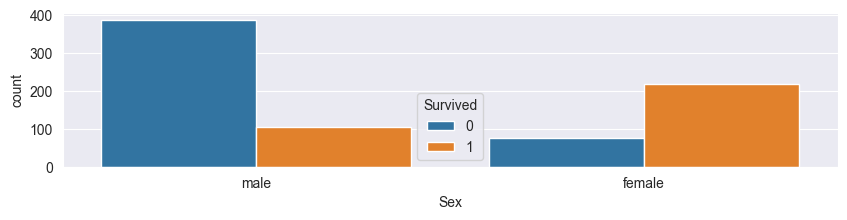

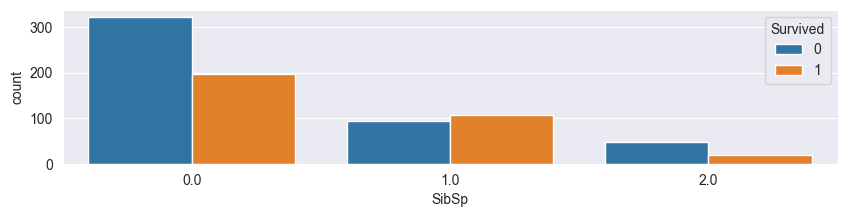

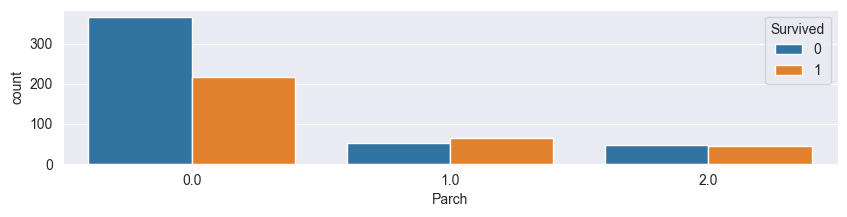

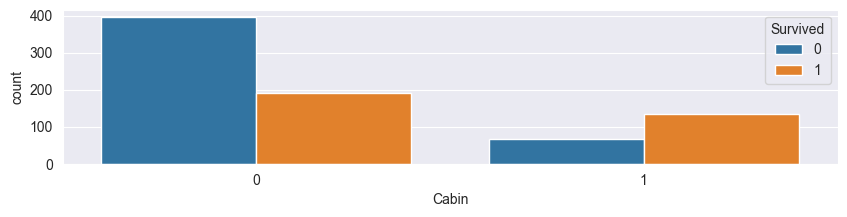

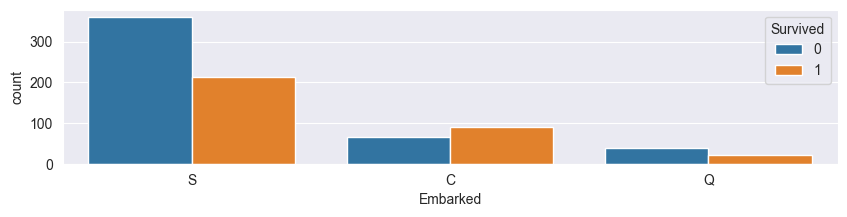

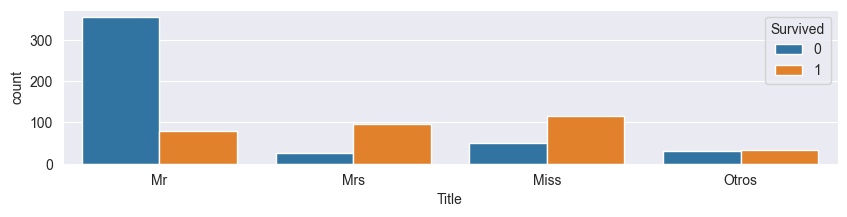

In [47]:
for col in cat_cols:
    plt.figure(figsize=(10,2))
    sns.countplot(data=df4, x=col, hue='Survived')
    plt.show()

In [74]:
""" OHE """

from sklearn.preprocessing import OneHotEncoder

# sex
X = df4[['Sex']]
ohe_sex = OneHotEncoder(drop='if_binary')
X_new = ohe_sex.fit_transform(X)

# embarked
X = df4[['Embarked']]
ohe_embarked = OneHotEncoder(drop='first')
X_new = ohe_embarked.fit_transform(X)

# title
X = df4[['Title']]
titles = [['Mr','Mrs','Miss']]
ohe_title = OneHotEncoder(categories=titles, handle_unknown='ignore')
X_new = ohe_title.fit_transform(X)

# X_new.toarray()[:10]

In [75]:
# ohe_title.get_feature_names_out()

# ColumnTransformer

In [86]:
from sklearn.compose import ColumnTransformer

ctransf = ColumnTransformer([
    ("imputer", KNNImputer(n_neighbors=5), ['Pclass','Age','SibSp', 'Parch','Fare']),
    ("ohe1", OneHotEncoder(drop='if_binary'), ['Sex']),
    ("ohe2", OneHotEncoder(drop='first'), ['Embarked']),
    ("ohe3", OneHotEncoder(categories=titles, handle_unknown='ignore'), ['Title']),
], remainder='passthrough')

ctransf.fit_transform(df4)

array([[ 3. , 22. ,  1. , ...,  0. ,  0. ,  0. ],
       [ 1. , 38. ,  1. , ...,  0. ,  1. ,  1. ],
       [ 3. , 26. ,  0. , ...,  1. ,  1. ,  0. ],
       ...,
       [ 3. , 26.8,  1. , ...,  1. ,  0. ,  0. ],
       [ 1. , 26. ,  0. , ...,  0. ,  1. ,  1. ],
       [ 3. , 32. ,  0. , ...,  0. ,  0. ,  0. ]])

In [87]:
ctransf.get_feature_names_out()

array(['imputer__Pclass', 'imputer__Age', 'imputer__SibSp',
       'imputer__Parch', 'imputer__Fare', 'ohe1__Sex_male',
       'ohe2__Embarked_Q', 'ohe2__Embarked_S', 'ohe3__Title_Mr',
       'ohe3__Title_Mrs', 'ohe3__Title_Miss', 'remainder__Survived',
       'remainder__Cabin'], dtype=object)

In [144]:
# Ejercicio
# columntransformer, imputer, ohes, standarscaler solo a las numericas, decisiontree

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

X = df4[cat_cols + num_cols]
y = df4['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)

ctransf = ColumnTransformer([
    ("imputer", KNNImputer(n_neighbors=5), ['Pclass','Age','SibSp', 'Parch','Fare']),
    ("ohe1", OneHotEncoder(drop='if_binary'), ['Sex']),
    ("ohe2", OneHotEncoder(drop='first'), ['Embarked']),
    ("ohe3", OneHotEncoder(categories=titles, handle_unknown='ignore'), ['Title']),
    ("scaler", StandardScaler(), ['Fare','Age'])
])

model = Pipeline([
    ("transformador", ctransf),
    ("dtc", DecisionTreeClassifier())
])
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.6772151898734177

In [111]:
model.steps[0][1].get_feature_names_out()

array(['imputer__Pclass', 'imputer__Age', 'imputer__SibSp',
       'imputer__Parch', 'imputer__Fare', 'ohe1__Sex_male',
       'ohe2__Embarked_Q', 'ohe2__Embarked_S', 'ohe3__Title_Mr',
       'ohe3__Title_Mrs', 'ohe3__Title_Miss', 'scaler__Fare',
       'scaler__Age'], dtype=object)

# Transformaciones numéricas

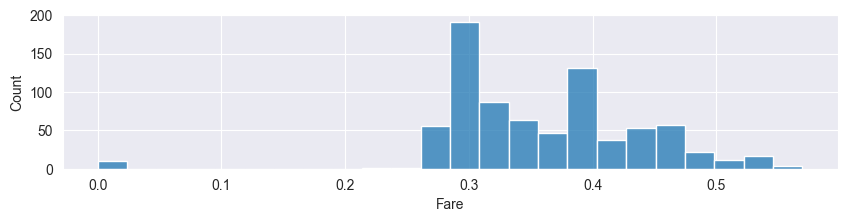

In [122]:
import numpy as np

X = df4['Fare']

X_new = np.log10(np.log10(X+1) + 1)

plt.figure(figsize=(10,2))
sns.histplot(X_new)
plt.show()

In [126]:
from sklearn.preprocessing import PowerTransformer

X = df4[['Age']]

pt = PowerTransformer(method='yeo-johnson')
X_new = pt.fit_transform(X)

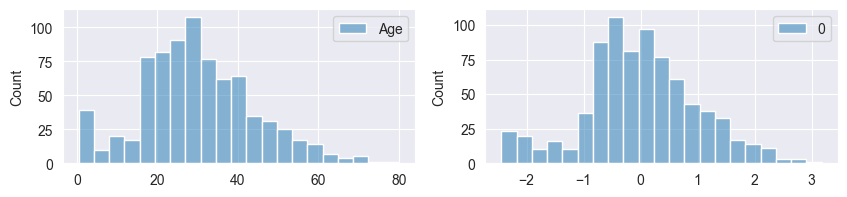

In [127]:
plt.figure(figsize=(10,2))
plt.subplot(1,2,1)
sns.histplot(X)
plt.subplot(1,2,2)
sns.histplot(X_new)
plt.show()

In [148]:
# Pipeline, column transformer -> ohes, imputer (nums), box-cox
# Random Forest

from sklearn.ensemble import RandomForestClassifier

ctransf = ColumnTransformer([
    ("imputer", KNNImputer(n_neighbors = 5), ['Pclass','Age','SibSp','Parch','Fare']),
    ("ohe1", OneHotEncoder(drop = 'if_binary'), ['Sex']),
    ("ohe2", OneHotEncoder(drop = 'first'), ['Embarked']),
    ("ohe3", OneHotEncoder(categories = titles, handle_unknown = 'ignore'),['Title']),
    ("powertransf", PowerTransformer(method = 'yeo-johnson'), ['Fare', 'Age'])
], remainder = 'passthrough')

model = Pipeline([
    ('transformador', ctransf),
    ('alg', RandomForestClassifier())
])

model.fit(X_train, y_train)

print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.9888888888888889
0.7341772151898734


In [156]:

ctransf = ColumnTransformer([
    ('imputer', KNNImputer(n_neighbors=5), ['Pclass','Age','SibSp','Parch','Fare']),
], remainder= 'passthrough')

ctransf2 = ColumnTransformer([
    ('ohe1', OneHotEncoder(drop = 'if_binary') , ['Sex']),
    ('ohe2', OneHotEncoder(drop = 'first') , ['Embarked']),
    ('ohe3', OneHotEncoder(categories = titles, handle_unknown = 'ignore'), ['Title']),
    ('Pt', PowerTransformer('yeo-johnson'), [8,11]),
    ]
)

model = Pipeline([
    ('coltransf', ctransf),
    ('coltransf2', ctransf2),
    ('tree', DecisionTreeClassifier() )
])


X = df4.drop(columns = 'Survived')
y = df4[['Survived']]


X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = .2)

model.fit(X_train, y_train)


ValueError: Specifying the columns using strings is only supported for dataframes.

In [157]:
ctransf.get_feature_names_out()

array(['imputer__Pclass', 'imputer__Age', 'imputer__SibSp',
       'imputer__Parch', 'imputer__Fare', 'remainder__Sex',
       'remainder__Cabin', 'remainder__Embarked', 'remainder__Title'],
      dtype=object)